# Семинар 1. Кластеризация
**Дополнительные главы машинного обучения**  
Образовательная программа «Машинное обучение в цифровом продукте»  
Автор занятия: Никитин Илья Сергеевич

В семинаре используются два набора данных. На истории заказов **Online Retail** рассматриваются
подготовка признаков покупателей, K-means, иерархическая кластеризация, DBSCAN и HDBSCAN.
На интервалах между извержениями **Old Faithful** разбирается EM-алгоритм для смеси двух
нормальных распределений.

Online Retail содержит заказы британского интернет-магазина. Среди клиентов есть оптовые
покупатели, поэтому один идентификатор может соответствовать как человеку, так и организации.

Chen, D. (2015). *Online Retail*. UCI Machine Learning Repository.
[DOI](https://doi.org/10.24432/C5BW33) ·
[Копия на Kaggle](https://www.kaggle.com/datasets/carrie1/ecommerce-data) ·
[Лицензия CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

In [1]:
from pathlib import Path
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '2')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.stats import norm
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.datasets import make_moons
from IPython.display import display

SEED = 42
COLORS = ['#28518d', '#cd7134', '#549879', '#9b6ca8', '#b8a044', '#5797ae', '#c75f83', '#847761', '#7396bb', '#757c3e']
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 110})
FIG = Path('Рисунки')
FIG.mkdir(exist_ok=True)

def savefig(name):
    for extension in ['pdf', 'png']:
        plt.gcf().savefig(FIG / f'lesson_01_{name}.{extension}', bbox_inches='tight', dpi=160)

raw = pd.read_csv('Данные/lesson_01_online_retail.csv.gz', encoding='ISO-8859-1',
                  dtype={'InvoiceNo': 'string', 'StockCode': 'string', 'CustomerID': 'string'},
                  parse_dates=['InvoiceDate'])
display(raw[['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'CustomerID']].head().rename(
    columns={'InvoiceNo': 'Заказ', 'StockCode': 'Товар', 'Quantity': 'Количество',
             'UnitPrice': 'Цена, £', 'CustomerID': 'Покупатель'}))

,Заказ,Товар,Количество,"Цена, £",Покупатель
0,536365,85123A,6,2.55,17850
1,536365,71053,6,3.39,17850
2,536365,84406B,8,2.75,17850
3,536365,84029G,6,3.39,17850
4,536365,84029E,6,3.39,17850


## Объекты и исходные записи

Строка исходной таблицы соответствует товарной позиции в заказе. Объектом кластеризации
будет покупатель, поэтому сначала нужно объединить строки в заказы, а заказы — в профиль
покупателя. Номера заказов и идентификаторы клиентов используются для такого объединения.
В признаки они не входят: численная разность идентификаторов не характеризует сходство покупателей.

Перед агрегацией проверим пропуски, отмены и повторяющиеся строки.
Отрицательное количество и номер заказа, начинающийся с `C`, могут обозначать отмену.
Записи без идентификатора покупателя нельзя связать с его остальными заказами.

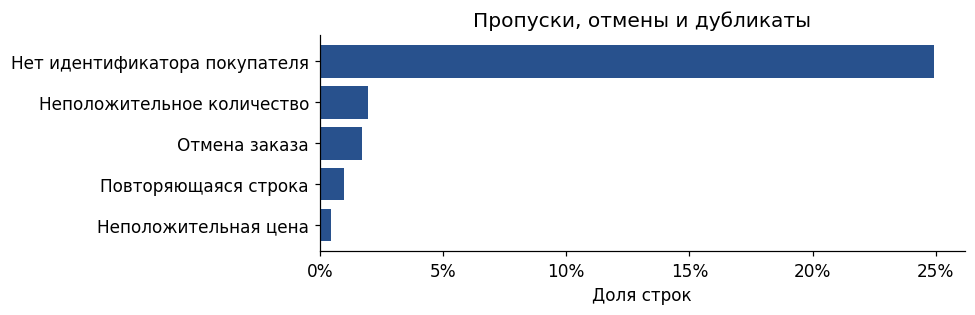

In [2]:
quality = pd.Series({
    'Нет идентификатора покупателя': raw.CustomerID.isna().mean(),
    'Отмена заказа': raw.InvoiceNo.str.upper().str.startswith('C').mean(),
    'Неположительное количество': raw.Quantity.le(0).mean(),
    'Неположительная цена': raw.UnitPrice.le(0).mean(),
    'Повторяющаяся строка': raw.duplicated().mean(),
}).sort_values()
fig, ax = plt.subplots(figsize=(9, 3))
ax.barh(quality.index, quality.values, color=COLORS[0])
ax.set(xlabel='Доля строк', title='Пропуски, отмены и дубликаты')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout(); plt.show()

Одна запись может одновременно попасть в несколько категорий на графике, поэтому доли
не следует складывать.

Для анализа покупательской активности оставим положительные продажи с известным клиентом
и товарным кодом, начинающимся с пяти цифр. Отмены исключим. Полученная сумма покупок
не учитывает последующие возвраты и потому не является чистой выручкой.

Выборку ограничим Великобританией, чтобы уменьшить различия, связанные с международной доставкой.
Точные дубликаты удалим как повторные записи. Это допущение подготовки данных:
одинаковые товарные строки иногда могут относиться к отдельным позициям заказа.

In [3]:
is_purchase = (
    raw.CustomerID.notna()
    & ~raw.InvoiceNo.str.upper().str.startswith('C')
    & raw.Quantity.gt(0)
    & raw.UnitPrice.gt(0)
    & raw.Country.eq('United Kingdom')
    & raw.StockCode.str.match(r'^\d{5}')
)
purchases = raw.loc[is_purchase].drop_duplicates().copy()
purchases['amount'] = purchases.Quantity * purchases.UnitPrice

# Объединяем товарные строки одного заказа перед подсчётом числа заказов.
orders = (purchases.groupby(['CustomerID', 'InvoiceNo'])
          .agg(date=('InvoiceDate', 'max'), amount=('amount', 'sum')).reset_index())
snapshot = raw.InvoiceDate.max().normalize() + pd.Timedelta(days=1)
customers = orders.groupby('CustomerID').agg(
    last_purchase=('date', 'max'), frequency=('InvoiceNo', 'nunique'),
    monetary=('amount', 'sum'), basket=('amount', 'mean'))
customers['recency'] = (snapshot - customers.last_purchase.dt.normalize()).dt.days
feature_names = ['recency', 'frequency', 'basket']
ru_names = ['Давность покупки', 'Число заказов', 'Средняя корзина']
features = customers[feature_names]
assert features.index.is_unique and features.notna().all().all()
assert (features > 0).all().all()
print(f'После подготовки: {len(orders):,} заказов и {len(customers):,} покупателей.'.replace(',', ' '))

После подготовки: 16 579 заказов и 3 916 покупателей.


## Признаки покупателей

Для каждого покупателя вычислим три признака:

- давность последней покупки в днях от общей даты среза;
- число заказов за весь период наблюдения;
- среднюю стоимость заказа.

Число заказов зависит в том числе от длительности наблюдения за покупателем:
у недавно появившегося клиента было меньше возможностей сделать повторный заказ.

Общая сумма покупок равна произведению числа заказов на среднюю стоимость заказа.
Включение всех трёх величин придало бы дополнительный вес одной и той же информации.
Поэтому общую сумму сохраним для описания групп, но исключим из признаков кластеризации.

Распределения признаков асимметричны. Длинные правые хвосты особенно заметны
у числа заказов и средней корзины.

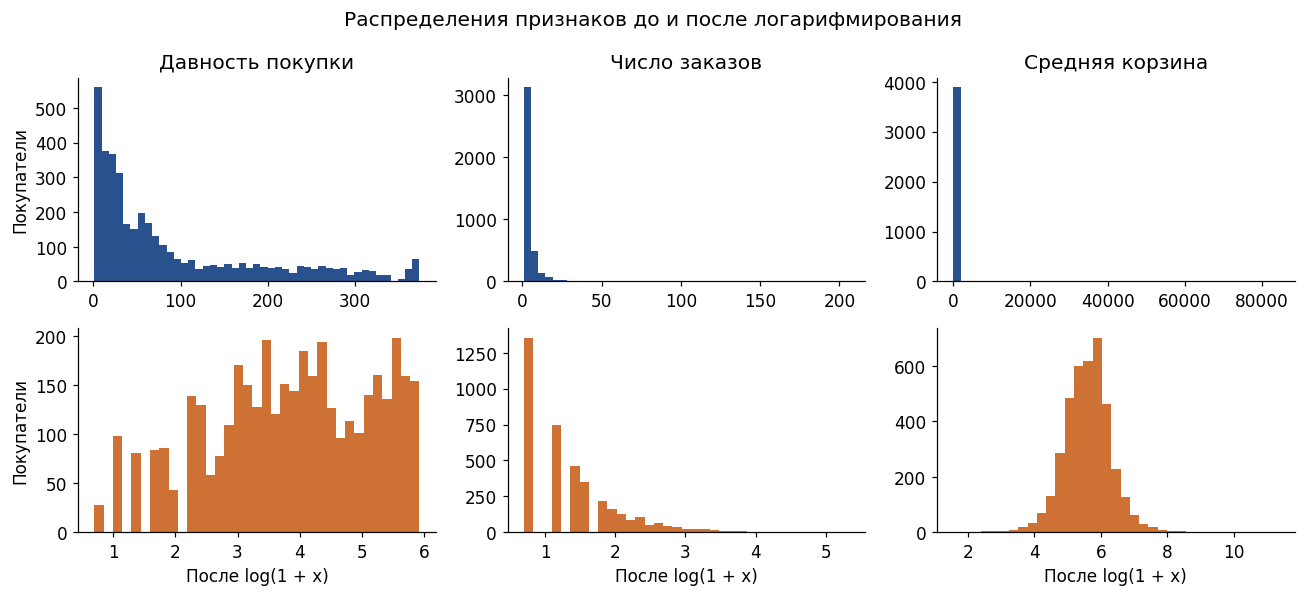

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5.5))
for j, (name, label) in enumerate(zip(feature_names, ru_names)):
    axes[0, j].hist(features[name], bins=45, color=COLORS[0])
    axes[0, j].set(title=label, ylabel='Покупатели' if j == 0 else '')
    axes[1, j].hist(np.log1p(features[name]), bins=35, color=COLORS[1])
    axes[1, j].set(xlabel='После log(1 + x)', ylabel='Покупатели' if j == 0 else '')
fig.suptitle('Распределения признаков до и после логарифмирования')
plt.tight_layout(); savefig('retail_distributions'); plt.show()

### Преобразование признаков

Большие значения признаков могут преобладать в евклидовых расстояниях.
Преобразование $\log(1+x)$ сжимает правый хвост и уменьшает влияние абсолютного масштаба различий.
После логарифмирования стандартизируем каждый столбец: вычтем среднее и разделим на стандартное
отклонение по выборке. Эту операцию выполняет `StandardScaler`.
На графиках стандартизованные значения обозначены $z$.

Преобразование меняет геометрию задачи. В частности, различия между крупными заказами становятся
менее выраженными. Если именно их абсолютная стоимость важна для анализа, такое сжатие может
оказаться нежелательным. Число заказов после преобразования по-прежнему принимает дискретный
набор значений.

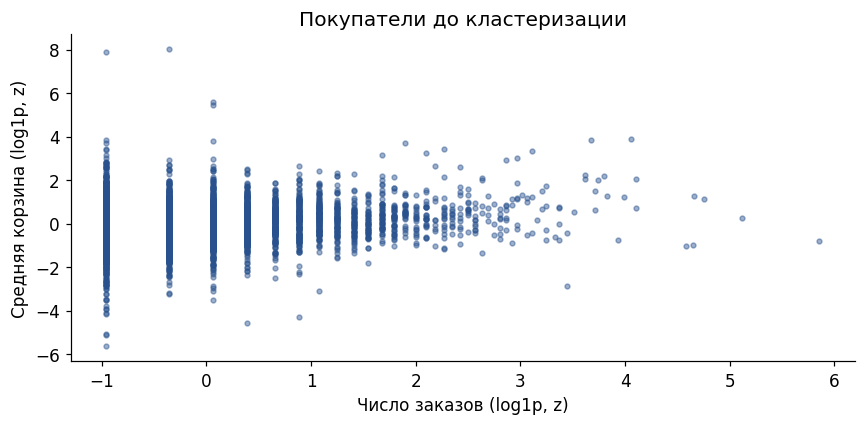

In [5]:
log_features = np.log1p(features)
scaler = StandardScaler()
Z = scaler.fit_transform(log_features)

def plot_customers(ax, labels, title):
    labels = np.asarray(labels)
    for label in sorted(set(labels)):
        mask = labels == label
        color = '#aaaaaa' if label < 0 else COLORS[label % len(COLORS)]
        ax.scatter(Z[mask, 1], Z[mask, 2], s=10, alpha=.45, color=color,
                   rasterized=True, label='Шум' if label < 0 else f'Группа {label + 1}')
    if len(set(labels)) > 1:
        ax.legend(loc='upper right', frameon=False, fontsize=8, markerscale=1.6, ncol=2)
    ax.set(title=title, xlabel='Число заказов (log1p, z)',
           ylabel='Средняя корзина (log1p, z)')

fig, ax = plt.subplots(figsize=(8, 4))
plot_customers(ax, np.zeros(len(Z), dtype=int), 'Покупатели до кластеризации')
plt.tight_layout(); plt.show()

## K-means

K-means описывает каждый кластер его центром — средним вектором признаков.
Алгоритм Ллойда чередует назначение объектов ближайшим центрам и пересчёт центров по назначенным
объектам. После пересчёта часть назначений может измениться, поэтому шаги повторяются.

Начнём с четырёх кластеров и рассмотрим их профили. Затем сравним разбиения при других
значениях числа кластеров.

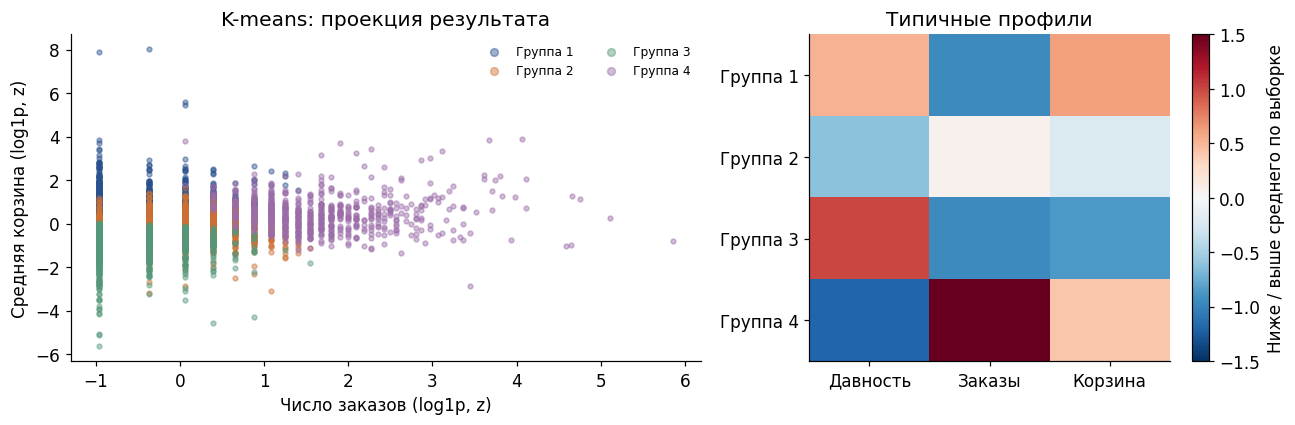

In [6]:
kmeans = KMeans(n_clusters=4, n_init=20, random_state=SEED)
labels_km = kmeans.fit_predict(Z)

def profile_plot(ax, labels, title):
    # Для каждой группы считаем медианы преобразованных признаков.
    # Они могут отличаться от центров, которые оптимизирует K-means.
    table = pd.DataFrame(Z, columns=ru_names).assign(group=labels)
    profile = table.loc[table.group >= 0].groupby('group')[ru_names].median()
    im = ax.imshow(profile, cmap='RdBu_r', vmin=-1.5, vmax=1.5, aspect='auto')
    ax.set_xticks(range(3), ['Давность', 'Заказы', 'Корзина'])
    ax.set_yticks(range(len(profile)), [f'Группа {i + 1}' for i in profile.index])
    ax.set_title(title)
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1.4, 1]})
plot_customers(axes[0], labels_km, 'K-means: проекция результата')
im = profile_plot(axes[1], labels_km, 'Типичные профили')
fig.colorbar(im, ax=axes[1], label='Ниже / выше среднего по выборке')
plt.tight_layout(); savefig('retail_kmeans'); plt.show()

На диаграмме рассеяния показаны два из трёх признаков. Кластеризация также учитывает давность
покупки, поэтому точки разных кластеров могут перекрываться в этой проекции.

Тепловая карта содержит медианы преобразованных признаков внутри кластеров.
Высокая давность соответствует покупателям, которые давно не возвращались, а большое число
заказов — покупателям с высокой активностью за период наблюдения.

Для интерпретации кластеров сопоставим их размеры и медианы в исходных единицах.
Такие профили описывают зарегистрированное поведение; сведений о доходе, возрасте и мотивах
покупателей в выбранных признаках нет.

In [7]:
profiles = customers.assign(group=labels_km).groupby('group').agg(
    Покупателей=('frequency', 'size'), Давность=('recency', 'median'),
    Заказы=('frequency', 'median'), Корзина=('basket', 'median'))
profiles.index = [f'Группа {i + 1}' for i in profiles.index]
display(profiles.round().astype(int).rename(columns={'Давность': 'Давность, дни', 'Корзина': 'Корзина, £'}))

,Покупателей,"Давность, дни",Заказы,"Корзина, £"
Группа 1,1155,93,1,418
Группа 2,1120,20,3,230
Группа 3,976,174,1,144
Группа 4,665,9,10,362


Полученные профили различаются давностью покупок, числом заказов и средней корзиной.
Например, выделяется группа с большим числом заказов и недавней последней покупкой.
Границы этих групп зависят от выбранных признаков, их преобразования и числа центров.

## Выбор числа кластеров

K-means строит разбиение и в том случае, когда в данных нет отчётливо разделённых групп.
При увеличении числа центров минимально достижимая сумма квадратов расстояний до них уменьшается.
Поэтому для выбора числа кластеров оценивают изменение этого критерия, а также отделённость групп.

Силуэт сопоставляет среднее расстояние до объектов своего кластера со средним расстоянием
до ближайшего другого кластера. На этой выборке наибольший силуэт среди рассмотренных вариантов
получается при двух кластерах. Более подробные разбиения позволяют различать дополнительные
профили, но их отделённость по этому критерию ниже.

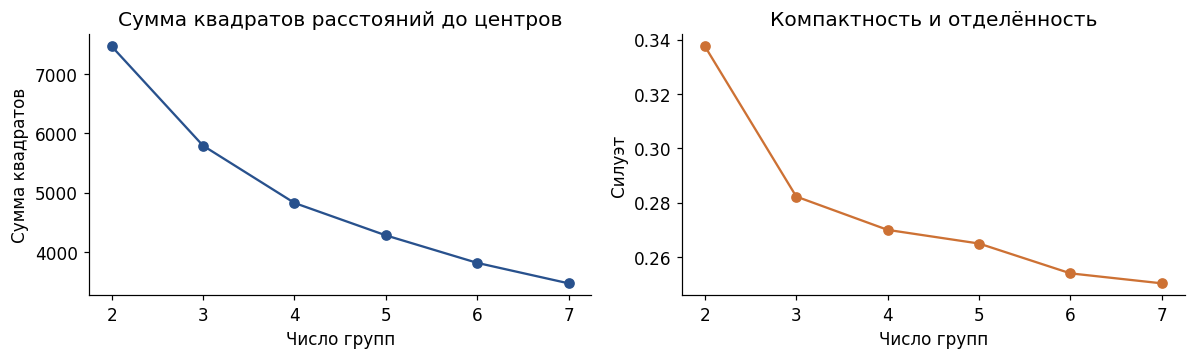

In [8]:
ks = range(2, 8)
models = [KMeans(k, n_init=20, random_state=SEED).fit(Z) for k in ks]
inertias = [m.inertia_ for m in models]
silhouettes = [silhouette_score(Z, m.labels_, sample_size=1200, random_state=SEED) for m in models]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(list(ks), inertias, 'o-', color=COLORS[0])
axes[0].set(xlabel='Число групп', ylabel='Сумма квадратов', title='Сумма квадратов расстояний до центров')
axes[1].plot(list(ks), silhouettes, 'o-', color=COLORS[1])
axes[1].set(xlabel='Число групп', ylabel='Силуэт', title='Компактность и отделённость')
plt.tight_layout(); savefig('retail_choose_k'); plt.show()

### Устойчивость разбиения

Проверим чувствительность K-means к составу выборки. В каждом повторе оставим случайные 80%
покупателей, заново оценим стандартизацию и построим разбиение на четыре кластера.
Назначения на оставшихся объектах сравним с назначениями исходной модели.

ARI (скорректированный индекс Рэнда) измеряет согласованность двух разбиений и не зависит
от нумерации кластеров. Значение 1 соответствует совпадению разбиений. Здесь исходная модель
служит точкой сравнения; высокая согласованность характеризует устойчивость, а не правильность
интерпретации групп.

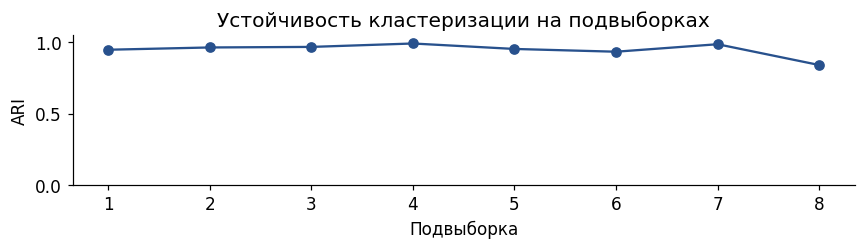

In [9]:
rng = np.random.default_rng(SEED)
stability = []
for _ in range(8):
    idx = rng.choice(len(Z), size=int(.8 * len(Z)), replace=False)
    subset_Z = StandardScaler().fit_transform(log_features.iloc[idx])
    model = KMeans(4, n_init=20, random_state=SEED).fit(subset_Z)
    stability.append(adjusted_rand_score(labels_km[idx], model.labels_))
fig, ax = plt.subplots(figsize=(8, 2.4))
ax.plot(range(1, len(stability) + 1), stability, 'o-', color=COLORS[0])
ax.set(ylim=(0, 1.05), xlabel='Подвыборка', ylabel='ARI', title='Устойчивость кластеризации на подвыборках')
plt.tight_layout(); plt.show()

## Иерархическая кластеризация

Агломеративный алгоритм начинает с отдельных объектов и последовательно объединяет группы.
Метод Уорда выбирает слияние с наименьшим приростом суммы квадратов расстояний до центров.
Как и K-means, он ориентирован на компактные группы. Уже выполненные слияния при этом сохраняются.

Дендрограмму построим на случайной подвыборке из 500 покупателей с фиксированным зерном генератора.
Для читаемости оставим 12 конечных ветвей. Число в скобках обозначает количество наблюдений
в свёрнутой ветви, а высота слияния отражает различие объединяемых групп по критерию Уорда.
Порядок листьев по горизонтали не задаёт шкалу расстояний.

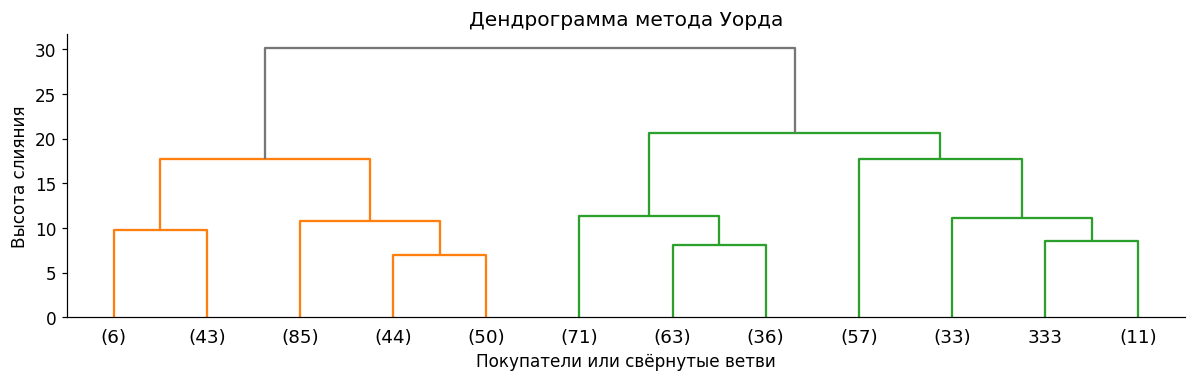

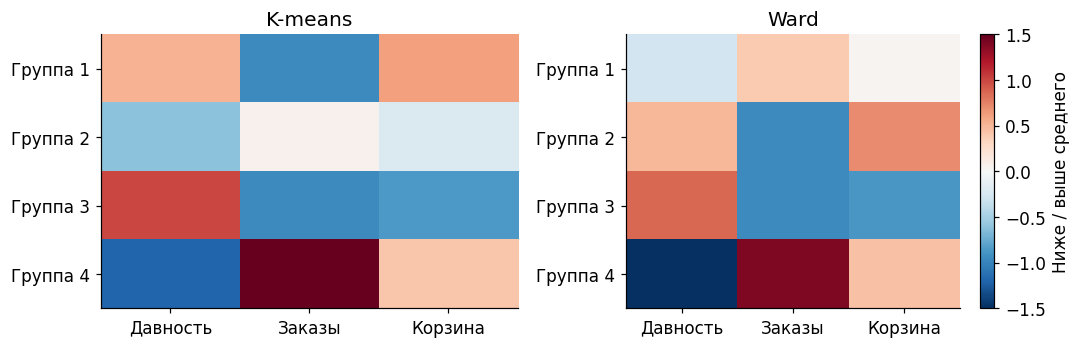

In [10]:
idx_tree = np.random.default_rng(SEED).choice(len(Z), size=500, replace=False)
tree = linkage(Z[idx_tree], method='ward')
fig, ax = plt.subplots(figsize=(11, 3.6))
dendrogram(tree, truncate_mode='lastp', p=12, show_leaf_counts=True, ax=ax,
           above_threshold_color='#777777')
ax.set(xlabel='Покупатели или свёрнутые ветви', ylabel='Высота слияния', title='Дендрограмма метода Уорда')
plt.tight_layout(); savefig('retail_tree'); plt.show()

labels_ward = AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(Z)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
profile_plot(axes[0], labels_km, 'K-means')
im = profile_plot(axes[1], labels_ward, 'Ward')
fig.colorbar(im, ax=axes[1], label='Ниже / выше среднего')
plt.tight_layout(); plt.show()

При сравнении тепловых карт нужно сопоставлять сами профили, поскольку номера кластеров
в K-means и методе Уорда не обязаны совпадать. Оба метода используют евклидовы расстояния
и критерии компактности, поэтому сходные результаты могут отражать общие предположения методов.

## DBSCAN

DBSCAN объединяет объекты через плотные окрестности. Основные параметры — радиус окрестности
$\varepsilon$ и минимальное число объектов в ней `min_samples`. Часть наблюдений может получить
метку шума и остаться вне кластеров.

Зафиксируем `min_samples=20` и сравним три радиуса: 0,25, 0,45 и 0,70.
На графиках шум отмечен серым.

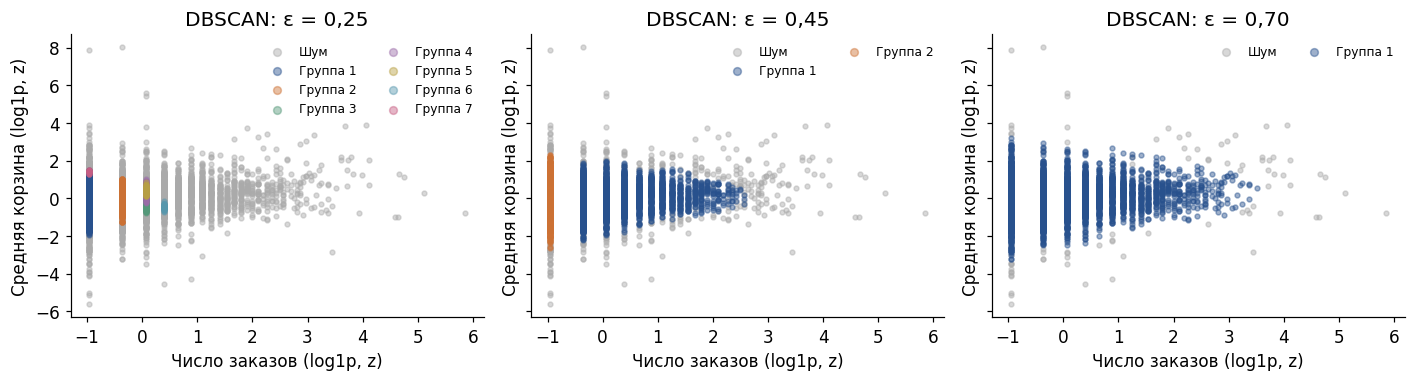

,Радиус ε,Групп,Вне групп
0,0.25,7,55%
1,0.45,2,10%
2,0.70,1,2%


In [11]:
radii = [.25, .45, .70]
density_labels = [DBSCAN(eps=eps, min_samples=20).fit_predict(Z) for eps in radii]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True, sharey=True)
for ax, labels, title in zip(axes, density_labels, ['DBSCAN: ε = 0,25', 'DBSCAN: ε = 0,45', 'DBSCAN: ε = 0,70']):
    plot_customers(ax, labels, title)
plt.tight_layout(); savefig('retail_dbscan'); plt.show()
display(pd.DataFrame({
    'Радиус ε': radii,
    'Групп': [len(set(labels) - {-1}) for labels in density_labels],
    'Вне групп': [f'{np.mean(labels < 0):.0%}' for labels in density_labels],
}))

В рассмотренных разбиениях увеличение радиуса приводит к слиянию плотных областей
и уменьшению доли шума. Метка шума зависит от признаков и параметров алгоритма.

## HDBSCAN

HDBSCAN строит иерархию плотных областей при разных уровнях плотности и выделяет устойчивые
кластеры. Единого радиуса $\varepsilon$ задавать не требуется. Параметр `min_cluster_size`
ограничивает минимальный размер кластера, а `min_samples` определяет требование к локальной
плотности. Рассмотрим результат при значениях 100 и 20 соответственно.

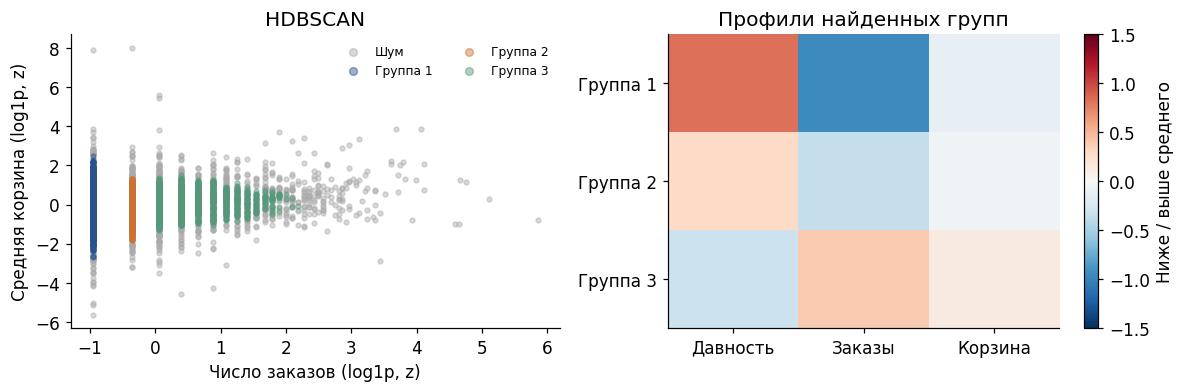

Вне групп осталось 24% покупателей.


In [12]:
hdb = HDBSCAN(min_cluster_size=100, min_samples=20, copy=True)
labels_hdb = hdb.fit_predict(Z)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.7))
plot_customers(axes[0], labels_hdb, 'HDBSCAN')
im = profile_plot(axes[1], labels_hdb, 'Профили найденных групп')
fig.colorbar(im, ax=axes[1], label='Ниже / выше среднего')
plt.tight_layout(); savefig('retail_hdbscan'); plt.show()
print(f'Вне групп осталось {np.mean(labels_hdb < 0):.0%} покупателей.')

Вертикальные полосы на проекции связаны с дискретным числом заказов. Плотностные методы
могут выделять их в отдельные кластеры. При интерпретации таких групп нужно учитывать,
что граница могла возникнуть из-за способа измерения признака.

Силуэт K-means на всей выборке и силуэт HDBSCAN после исключения шума относятся к разным
наборам объектов. Для сравнения методов следует также учитывать долю наблюдений,
оставшихся вне кластеров, и их признаки.

## EM-алгоритм: интервалы между извержениями

Набор **Old Faithful** содержит наблюдения гейзера в Йеллоустонском национальном парке.
Используем все 272 значения признака `waiting` — интервала до следующего извержения в минутах.
Метки принадлежности наблюдений к группам в таблице отсутствуют.

Распределение интервалов имеет две выраженные моды. Для его описания рассмотрим смесь
двух нормальных распределений. Параметры смеси оценим EM-алгоритмом в исходных единицах измерения.

Набор `faithful` из пакета R `datasets`; источник этой версии — W. Härdle.
[Описание данных](https://search.r-project.org/R/refmans/datasets/html/faithful.html) ·
[CSV](https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/faithful.csv).

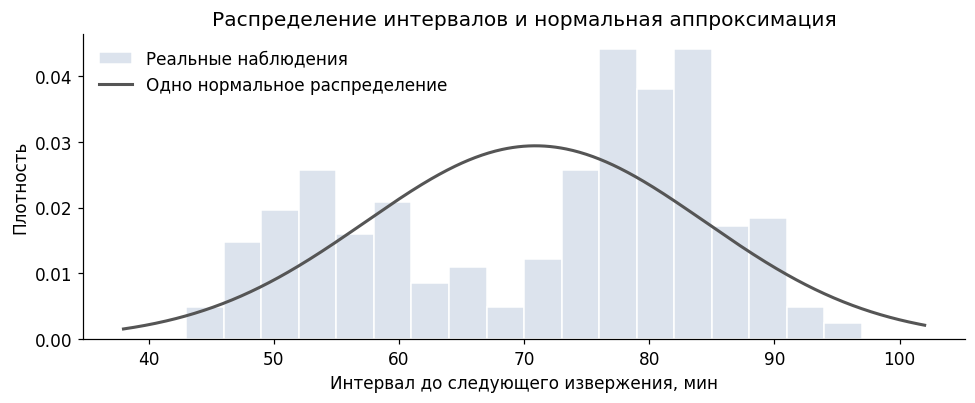

Наблюдений: 272; интервал: от 43 до 96 мин.


In [13]:
faithful = pd.read_csv('Данные/lesson_01_old_faithful.csv')
x = faithful['waiting'].to_numpy(dtype=float)
assert len(x) == 272 and np.isfinite(x).all()
X_waiting = x[:, None]  # scikit-learn ожидает таблицу «объекты × признаки».
grid = np.linspace(38, 102, 600)
hist_bins = np.arange(40, 100, 3)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(x, bins=hist_bins, density=True, color='#dce3ed', edgecolor='white',
        label='Реальные наблюдения')
ax.plot(grid, norm.pdf(grid, x.mean(), x.std(ddof=0)), color='#555555', lw=2,
        label='Одно нормальное распределение')
ax.set(xlabel='Интервал до следующего извержения, мин', ylabel='Плотность',
       title='Распределение интервалов и нормальная аппроксимация')
ax.legend(frameon=False)
plt.tight_layout(); savefig('faithful_data'); plt.show()
print(f'Наблюдений: {len(x)}; интервал: от {x.min():.0f} до {x.max():.0f} мин.')

### Модель смеси

Среднее всей выборки находится между двумя модами. Одна нормальная плотность имеет максимум
в этой области и плохо описывает наблюдаемую форму распределения. В смеси одна компонента
будет описывать сравнительно короткие ожидания, другая — долгие.

Плотность для отдельного интервала $x$ имеет вид

$$p(x)=\pi_1\mathcal N(x\mid\mu_1,\sigma_1^2)
      +\pi_2\mathcal N(x\mid\mu_2,\sigma_2^2),\qquad
\pi_1+\pi_2=1,\quad \pi_k>0.$$

Здесь $\mu_k$ — среднее компоненты $k$, $\sigma_k$ — её стандартное отклонение,
$\pi_k$ — доля компоненты в смеси. Условие $\pi_1+\pi_2=1$ обеспечивает единичную площадь
под суммарной плотностью.

При известной принадлежности наблюдений параметры можно было бы оценить отдельно для каждой
группы. При известных параметрах можно было бы вычислить вероятности принадлежности.
EM решает эти две задачи поочерёдно: по текущим параметрам находит вероятности,
затем использует их как веса для пересчёта параметров. В области перекрытия обе компоненты
могут получать заметный вес от одного наблюдения.

Начальные средние зададим равными 60 и 75 минутам, стандартные отклонения — 10 минутам,
доли — 0,5. Далее эти значения будут уточняться по выборке.

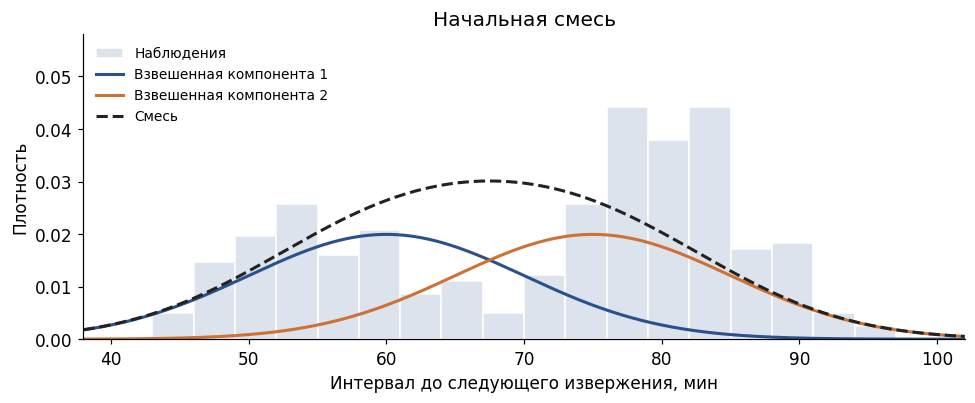

In [14]:
initial_means = np.array([60., 75.])
initial_variances = np.array([100., 100.])
initial_weights = np.array([.5, .5])

def plot_mixture(ax, means, variances, weights, title):
    ax.hist(x, bins=hist_bins, density=True, color='#dce3ed', edgecolor='white',
            label='Наблюдения')
    densities = weights * norm.pdf(grid[:, None], means, np.sqrt(variances))
    for k in range(len(means)):
        ax.plot(grid, densities[:, k], color=COLORS[k], lw=2,
                label=f'Взвешенная компонента {k + 1}')
    ax.plot(grid, densities.sum(axis=1), '--', color='#222222', lw=2, label='Смесь')
    ax.set(title=title, xlabel='Интервал до следующего извержения, мин',
           ylabel='Плотность', xlim=(38, 102), ylim=(0, .058))

fig, ax = plt.subplots(figsize=(9, 3.8))
plot_mixture(ax, initial_means, initial_variances, initial_weights, 'Начальная смесь')
ax.legend(fontsize=9, frameon=False)
plt.tight_layout(); plt.show()

### E-шаг

Для интервала 67 минут вычислим значение плотности каждой компоненты и умножим его
на долю этой компоненты. Затем разделим каждое из двух полученных чисел на их сумму.
Результат — вероятности принадлежности интервала компонентам при текущих параметрах.

Для наблюдения $x_i$ эти вероятности обозначаются $r_{i1}$ и $r_{i2}$:

$$r_{ik}=\frac{\pi_k\mathcal N(x_i\mid\mu_k,\sigma_k^2)}
{\pi_1\mathcal N(x_i\mid\mu_1,\sigma_1^2)+\pi_2\mathcal N(x_i\mid\mu_2,\sigma_2^2)}.$$

Их сумма для каждого наблюдения равна единице. На E-шаге параметры компонент фиксированы;
вычисленные вероятности используются как веса на следующем шаге.
В реализации применяются логарифмы и `logsumexp`, чтобы избежать потери точности при малых плотностях.

,"Интервал, мин",Взвешенная плотность 1,Взвешенная плотность 2,Вероятность компоненты 1,Вероятность компоненты 2
0,55.0,0.0176,0.0027,0.8670,0.1330
1,67.0,0.0156,0.0145,0.5187,0.4813
2,80.0,0.0027,0.0176,0.1330,0.8670


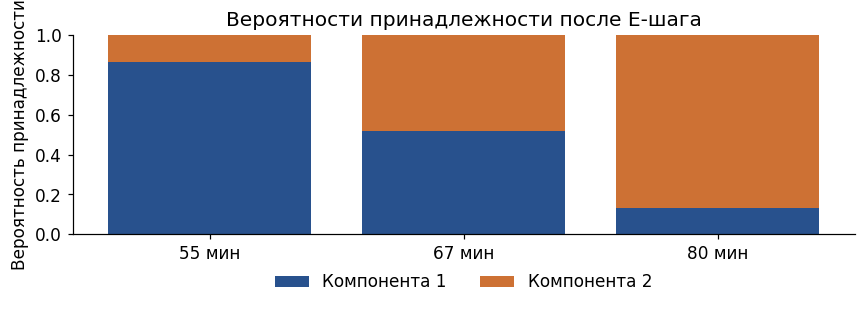

In [15]:
def expectation(values, means, variances, weights):
    log_joint = np.log(weights) + norm.logpdf(values[:, None], means, np.sqrt(variances))
    log_density = logsumexp(log_joint, axis=1)
    responsibilities = np.exp(log_joint - log_density[:, None])
    return responsibilities, log_density.sum()

r_initial, initial_likelihood = expectation(
    x, initial_means, initial_variances, initial_weights)
assert np.allclose(r_initial.sum(axis=1), 1)

# Все три значения встречаются в исходной выборке.
example_values = np.array([55., 67., 80.])
assert np.isin(example_values, x).all()
example_r, _ = expectation(example_values, initial_means, initial_variances, initial_weights)
weighted_densities = initial_weights * norm.pdf(
    example_values[:, None], initial_means, np.sqrt(initial_variances))
display(pd.DataFrame({
    'Интервал, мин': example_values,
    'Взвешенная плотность 1': weighted_densities[:, 0],
    'Взвешенная плотность 2': weighted_densities[:, 1],
    'Вероятность компоненты 1': example_r[:, 0],
    'Вероятность компоненты 2': example_r[:, 1],
}).round(4))

fig, ax = plt.subplots(figsize=(8, 3))
labels = [f'{value:.0f} мин' for value in example_values]
ax.bar(labels, example_r[:, 0], color=COLORS[0], label='Компонента 1')
ax.bar(labels, example_r[:, 1], bottom=example_r[:, 0], color=COLORS[1], label='Компонента 2')
ax.set(ylabel='Вероятность принадлежности', ylim=(0, 1), title='Вероятности принадлежности после E-шага')
ax.legend(loc='upper center', bbox_to_anchor=(.5, -.12), ncol=2, frameon=False)
plt.tight_layout(); plt.show()

### M-шаг

Зафиксируем вероятности, полученные на E-шаге, и оценим параметры компонент.
Наблюдение с весом 0,9 влияет на оценку среднего сильнее, чем наблюдение с весом 0,1.
Таким образом, среднее каждой компоненты вычисляется по всем наблюдениям с соответствующими весами.

Сумма весов $N_k=\sum_i r_{ik}$ — эффективное число наблюдений в компоненте;
оно не обязано быть целым. При $n=272$ наблюдениях формулы обновления имеют вид

$$\mu_k^{new}=\frac{\sum_i r_{ik}x_i}{N_k},\qquad
(\sigma_k^2)^{new}=\frac{\sum_i r_{ik}(x_i-\mu_k^{new})^2}{N_k},\qquad
\pi_k^{new}=\frac{N_k}{n}.$$

Дисперсия вычисляется относительно нового среднего. Деление на $N_k$ соответствует
оценке максимального правдоподобия. После обновления параметров повторяется E-шаг,
поскольку вероятности принадлежности тоже изменяются.

In [16]:
def maximization(values, responsibilities):
    mass = responsibilities.sum(axis=0)
    new_means = (responsibilities * values[:, None]).sum(axis=0) / mass
    new_variances = (responsibilities * (values[:, None] - new_means)**2).sum(axis=0) / mass
    # Защита от нулевой дисперсии; в этом примере граница не достигается.
    return new_means, np.maximum(new_variances, 1e-6), mass / len(values)

first_means, first_variances, first_weights = maximization(x, r_initial)
display(pd.DataFrame({
    'Компонента': [1, 2],
    'Сумма весов N_k': r_initial.sum(axis=0),
    'Среднее до шага, мин': initial_means,
    'Среднее после шага, мин': first_means,
    'Станд. отклонение после шага, мин': np.sqrt(first_variances),
    'Доля после шага': first_weights,
}).round(3))

,Компонента,Сумма весов N_k,"Среднее до шага, мин","Среднее после шага, мин","Станд. отклонение после шага, мин",Доля после шага
0,1,110.75,60.0,59.488,11.193,0.407
1,2,161.25,75.0,78.733,8.588,0.593


### Итерации и критерий остановки

Одна итерация включает E-шаг и M-шаг. Качество текущих параметров оценивается
логарифмическим правдоподобием — суммой логарифмов плотности смеси в наблюдаемых точках:

$$\ell(\theta)=\sum_{i=1}^n\log p(x_i\mid\theta),$$

где $\theta$ объединяет средние, дисперсии и доли компонент.
Итерации прекращаются, когда изменение этого критерия становится меньше заданного порога.
На графиках показаны параметры начальной смеси и результаты нескольких итераций
для одной и той же выборки.

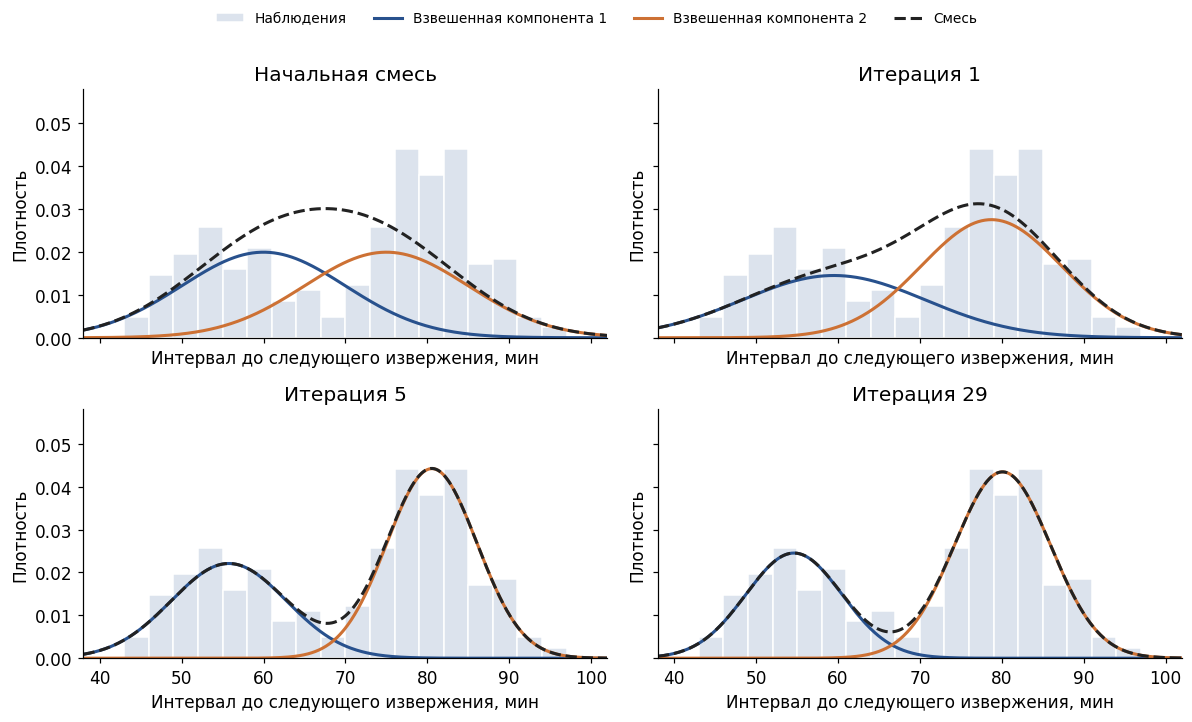

,Компонента,Доля,"Среднее, мин","Стандартное отклонение, мин"
0,Короткое ожидание,0.361,54.615,5.871
1,Долгое ожидание,0.639,80.091,5.868


In [17]:
def fit_em_1d(values, means, variances, weights, max_iter=500, tol=1e-8):
    means, variances, weights = [np.array(v, dtype=float, copy=True)
                                for v in (means, variances, weights)]
    history = [(means.copy(), variances.copy(), weights.copy())]
    likelihood = [expectation(values, means, variances, weights)[1]]
    for _ in range(max_iter):
        responsibilities, _ = expectation(values, means, variances, weights)
        means, variances, weights = maximization(values, responsibilities)
        history.append((means.copy(), variances.copy(), weights.copy()))
        likelihood.append(expectation(values, means, variances, weights)[1])
        if abs(likelihood[-1] - likelihood[-2]) < tol:
            break
    else:
        raise RuntimeError('EM не сошёлся за заданное число итераций.')
    assert np.all(np.diff(likelihood) >= -1e-7), 'Правдоподобие не должно убывать.'
    return history, np.asarray(likelihood)

history, likelihood = fit_em_1d(x, initial_means, initial_variances, initial_weights)
means, variances, weights = history[-1]
r_final, _ = expectation(x, means, variances, weights)
assert np.allclose(r_final.sum(axis=1), 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 6.6), sharex=True, sharey=True)
steps = [0, 1, min(5, len(history) - 1), len(history) - 1]
for ax, step in zip(axes.flat, steps):
    plot_mixture(ax, *history[step], 'Начальная смесь' if step == 0 else f'Итерация {step}')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False, fontsize=9)
plt.tight_layout(rect=(0, 0, 1, .94)); savefig('faithful_em'); plt.show()

parameter_table = pd.DataFrame({
    'Компонента': ['Короткое ожидание', 'Долгое ожидание'],
    'Доля': weights,
    'Среднее, мин': means,
    'Стандартное отклонение, мин': np.sqrt(variances),
})
display(parameter_table.round(3))

Оценки средних составили около 54,6 и 80,1 минуты, долей — 0,36 и 0,64.
Смесь описывает обе моды распределения и более высокую долю долгих ожиданий.
Нормальные компоненты здесь служат приближённой моделью распределения измерений.

График правдоподобия позволяет проверить его неубывание на итерациях EM.
Вероятности принадлежности показывают неопределённость в области перекрытия компонент:
для промежуточных интервалов ни одна из них не получает вероятность, близкую к единице.

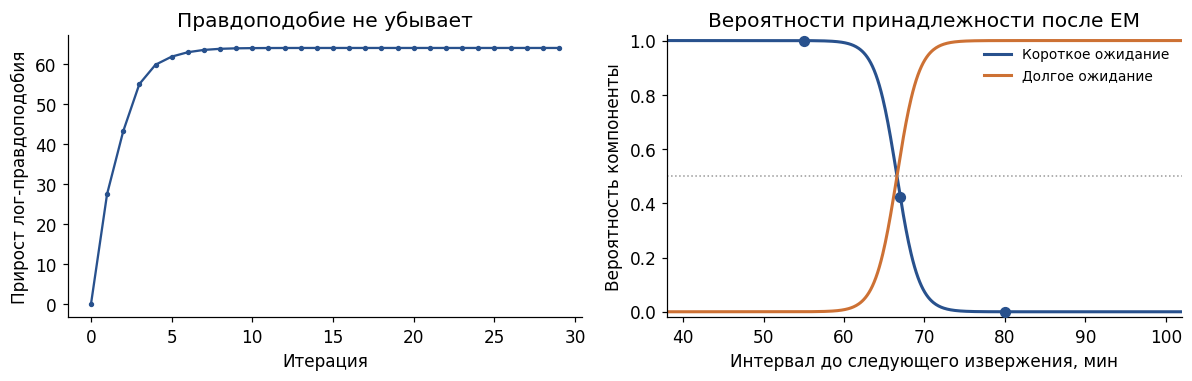

,"Интервал, мин",Вероятность короткого ожидания до EM,Вероятность короткого ожидания после EM
0,55.0,0.8670,0.9998
1,67.0,0.5187,0.4235
2,80.0,0.1330,0.0000


In [18]:
grid_r, _ = expectation(grid, means, variances, weights)
final_example_r, _ = expectation(example_values, means, variances, weights)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(likelihood - likelihood[0], color=COLORS[0], marker='.', ms=5)
axes[0].set(xlabel='Итерация', ylabel='Прирост лог-правдоподобия',
            title='Правдоподобие не убывает')
for k, label in enumerate(['Короткое ожидание', 'Долгое ожидание']):
    axes[1].plot(grid, grid_r[:, k], color=COLORS[k], lw=2, label=label)
axes[1].axhline(.5, ls=':', color='#999999', lw=1)
axes[1].scatter(example_values, final_example_r[:, 0], color=COLORS[0], s=40, zorder=3)
axes[1].set(xlabel='Интервал до следующего извержения, мин', ylabel='Вероятность компоненты',
            title='Вероятности принадлежности после EM', ylim=(-.02, 1.02), xlim=(38, 102))
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout(); savefig('faithful_responsibilities'); plt.show()
display(pd.DataFrame({
    'Интервал, мин': example_values,
    'Вероятность короткого ожидания до EM': example_r[:, 0],
    'Вероятность короткого ожидания после EM': final_example_r[:, 0],
}).round(4))

### Реализация в scikit-learn

`GaussianMixture` оценивает параметры смеси с помощью EM. Передадим ему таблицу с одним
столбцом, зададим две компоненты и несколько инициализаций. Из полученных решений библиотека
выберет вариант с наибольшим правдоподобием.

Для сравнения с ручной реализацией упорядочим компоненты по среднему.
Это устраняет различия, связанные с произвольной нумерацией компонент.

,Компонента,Среднее: ручной EM,Среднее: scikit-learn,Доля: ручной EM,Доля: scikit-learn
0,1,54.6149,54.6154,0.3609,0.3609
1,2,80.0911,80.0914,0.6391,0.6391


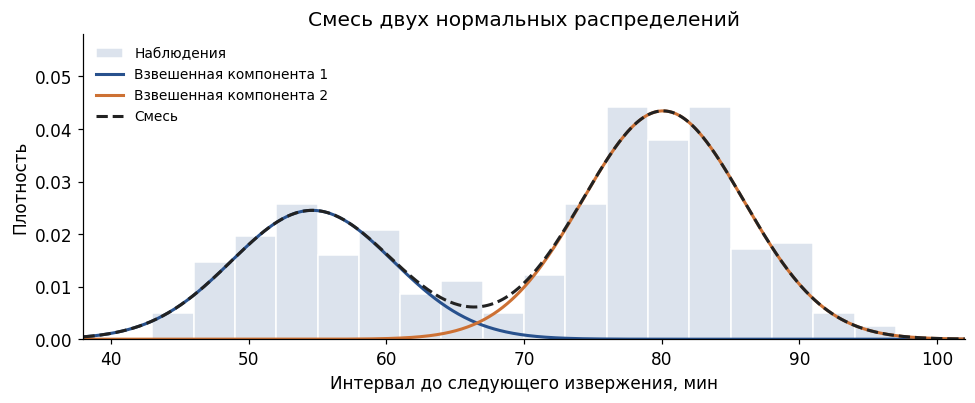

In [19]:
gmm = GaussianMixture(n_components=2, n_init=10, max_iter=500, tol=1e-8,
                      reg_covar=1e-6, random_state=SEED).fit(X_waiting)
assert gmm.converged_
component_order = np.argsort(gmm.means_[:, 0])
sk_means = gmm.means_[component_order, 0]
sk_variances = gmm.covariances_[component_order, 0, 0]
sk_weights = gmm.weights_[component_order]
assert np.allclose(means, sk_means, atol=2e-3)
assert np.allclose(np.sqrt(variances), np.sqrt(sk_variances), atol=2e-3)
assert np.allclose(weights, sk_weights, atol=2e-4)

display(pd.DataFrame({
    'Компонента': [1, 2],
    'Среднее: ручной EM': means,
    'Среднее: scikit-learn': sk_means,
    'Доля: ручной EM': weights,
    'Доля: scikit-learn': sk_weights,
}).round(4))
fig, ax = plt.subplots(figsize=(9, 3.8))
plot_mixture(ax, sk_means, sk_variances, sk_weights, 'Смесь двух нормальных распределений')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); savefig('faithful_gmm'); plt.show()

### Выбор числа компонент по BIC

Сравним смеси с одной, двумя, тремя и четырьмя компонентами на тех же наблюдениях.
Увеличение числа компонент позволяет точнее подогнать плотность, поэтому при выборе модели
нужно учитывать её сложность.

Байесовский информационный критерий BIC имеет вид

$$\mathrm{BIC}=-2\ell(\widehat\theta)+m\log n.$$

Здесь $n$ — число наблюдений, $m$ — число свободных параметров, $\widehat\theta$ — оценки
параметров модели. Для одномерной смеси с отдельной дисперсией каждой компоненты
$m=K+K+(K-1)=3K-1$: $K$ средних, $K$ дисперсий и $K-1$ независимых долей.

Меньшее значение BIC предпочтительнее. Критерий сравнивает статистические модели;
число компонент не обязательно совпадает с числом физических состояний гейзера.

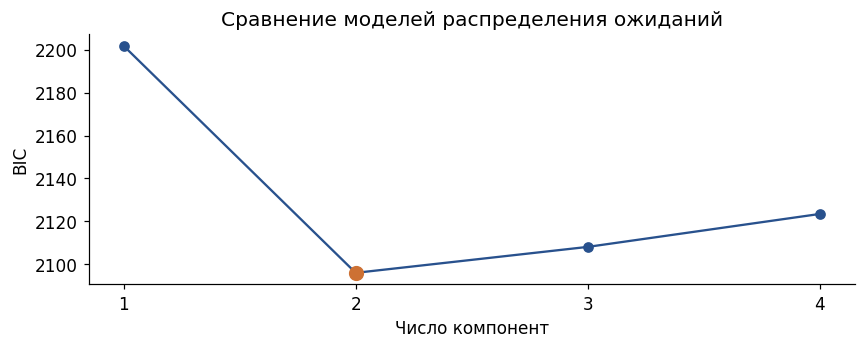

,Компоненты,BIC
0,1,2201.79
1,2,2096.03
2,3,2108.12
3,4,2123.47


Число компонент с минимальным BIC: 2.


In [20]:
component_counts = range(1, 5)
mixtures = [GaussianMixture(n_components=k, n_init=10, max_iter=1000, tol=1e-6,
                           reg_covar=1e-6, random_state=SEED).fit(X_waiting)
            for k in component_counts]
assert all(model.converged_ for model in mixtures)
bics = np.array([model.bic(X_waiting) for model in mixtures])
best_k = list(component_counts)[int(np.argmin(bics))]
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.plot(list(component_counts), bics, 'o-', color=COLORS[0])
ax.scatter([best_k], [bics.min()], color=COLORS[1], s=80, zorder=3)
ax.set(xticks=list(component_counts), xlabel='Число компонент', ylabel='BIC',
       title='Сравнение моделей распределения ожиданий')
plt.tight_layout(); savefig('faithful_bic'); plt.show()
display(pd.DataFrame({'Компоненты': list(component_counts), 'BIC': bics}).round(2))
print(f'Число компонент с минимальным BIC: {best_k}.')

### Одинаковая инициализация

Рассмотрим запуск EM с одинаковыми начальными средними, дисперсиями и долями компонент.
Средние и дисперсии зададим по всей выборке, доли — равными 0,5.

На E-шаге обе компоненты получают вес 0,5 для каждого наблюдения.
На M-шаге их средние и дисперсии остаются равны среднему и дисперсии всей выборки.
Последующие итерации сохраняют совпадение параметров. Сумма двух таких компонент равна
одной нормальной плотности.

Разные начальные средние нарушают симметрию компонент. Несколько инициализаций позволяют
сравнить решения, к которым EM сходится из разных начальных точек.

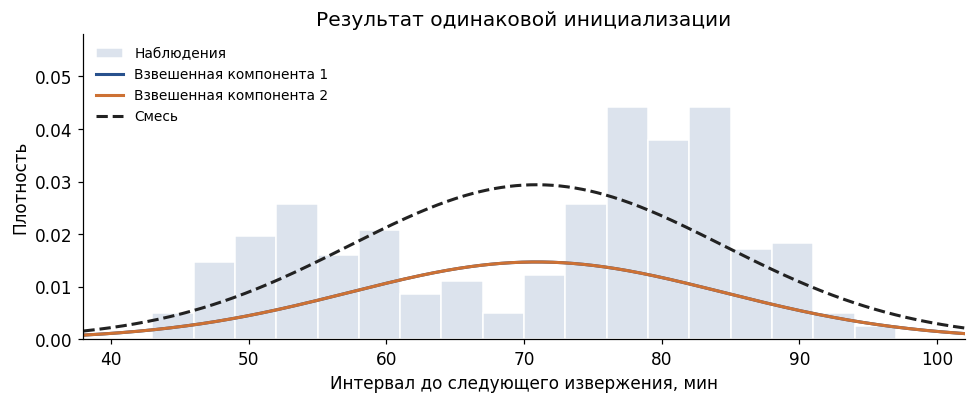

Разница лог-правдоподобий: 61.28705066430825


In [21]:
symmetric_history, symmetric_ll = fit_em_1d(
    x,
    means=[x.mean(), x.mean()],
    variances=[x.var(), x.var()],
    weights=[.5, .5],
)
fig, ax = plt.subplots(figsize=(9, 3.8))
plot_mixture(ax, *symmetric_history[-1], 'Результат одинаковой инициализации')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
print('Разница лог-правдоподобий:', likelihood[-1] - symmetric_ll[-1])

## Геометрия кластеров

В завершение сравним K-means и DBSCAN на двух изогнутых полосах с небольшим шумом.
В этом примере форма групп задана при генерации данных. Он позволяет отдельно рассмотреть
влияние предположений методов: K-means использует близость к центру, а DBSCAN — плотностную связность.

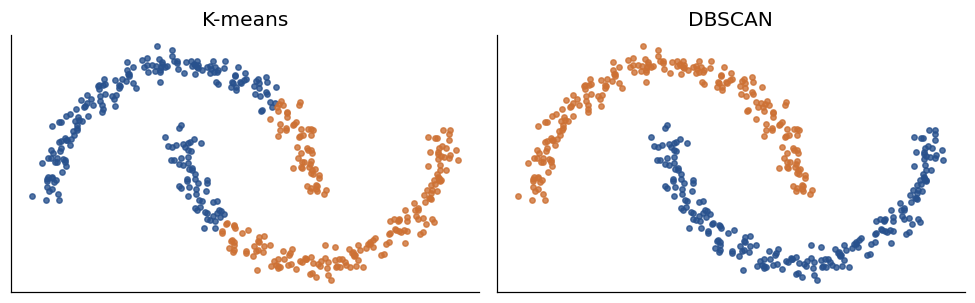

In [22]:
moons, _ = make_moons(n_samples=450, noise=.055, random_state=SEED)
demo_models = [KMeans(2, n_init=20, random_state=SEED), DBSCAN(eps=.18, min_samples=6)]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, model, title in zip(axes, demo_models, ['K-means', 'DBSCAN']):
    labels = model.fit_predict(moons)
    for label in sorted(set(labels)):
        mask = labels == label
        ax.scatter(*moons[mask].T, s=12, color='#aaaaaa' if label < 0 else COLORS[label], alpha=.8)
    ax.set(title=title, xticks=[], yticks=[])
    ax.set_aspect('equal')
plt.tight_layout(); savefig('geometry_comparison'); plt.show()

## Итоги семинара

- **K-means и метод Уорда.** Оба метода выделяют компактные группы. K-means строит разбиение
  при заданном числе центров, а метод Уорда формирует иерархию последовательных объединений.
- **DBSCAN и HDBSCAN.** Плотностные методы позволяют выделять группы сложной формы
  и оставлять часть объектов вне кластеров. Результат зависит от локальной плотности,
  параметров и особенностей измерения признаков.
- **EM и смесь нормальных распределений.** На интервалах Old Faithful двухкомпонентная смесь
  описала две моды. E-шаг вычисляет вероятности принадлежности, M-шаг обновляет параметры
  с этими весами. Результат зависит от инициализации.
- **Оценка результата.** Силуэт характеризует компактность и отделённость кластеров,
  ARI позволяет сравнить разбиения, а BIC — модели плотности с разным числом параметров.
  Эти критерии решают разные задачи и не заменяют интерпретацию полученных групп.

При сравнении разбиений необходимо учитывать признаки, масштабирование, состав оцениваемой
выборки и долю объектов, отнесённых к шуму. Геометрический пример показал, что различия
между методами могут определяться формой групп даже при одинаковых исходных данных.

### Литература

- scikit-learn developers. *Clustering*.
  [Документация](https://scikit-learn.org/stable/modules/clustering.html).
- scikit-learn developers. *Gaussian mixture models*.
  [Документация](https://scikit-learn.org/stable/modules/mixture.html).
- Dempster, A. P., Laird, N. M., Rubin, D. B. (1977).
  *Maximum Likelihood from Incomplete Data via the EM Algorithm*.
  [Статья](https://doi.org/10.1111/j.2517-6161.1977.tb01600.x).